
# Practical 22: Binary Segmentation using U‑Net
  
**Goal:** Build, train, and evaluate a **U‑Net** model for **binary image segmentation** (horse vs. background) on the **Weizmann Horse** dataset.

---

### What you'll learn
- The **problem setup** for **semantic segmentation** vs. classification/detection.
- The **U‑Net architecture** (encoder–decoder with skip connections): *why it works and how to implement it*.
- A clean **PyTorch pipeline** for segmentation: dataset class, transforms/augmentations, model, loss, metrics, visualizations.
- **Metrics for segmentation**: IoU (Jaccard), Dice, Precision/Recall; thresholding & post‑processing basics.
- **Training tips**: balancing foreground/background, data augmentations, and monitoring overfitting.



## How this connects with earlier Practicals
- **Practical 7 (CNN & AlexNet)** taught convolution basics ➜ here we reuse conv blocks but aim for **per‑pixel** labels.
- **Practicals 8–11 (VGG, GoogLeNet, ResNet)** showed deep feature extractors ➜ U‑Net's **encoder** shares that spirit.
- **Practical 4 & 15 (Transfer Learning; Freeze vs. Fine‑Tune)** ➜ you can swap U‑Net's encoder with a pretrained backbone later.
- **Practical 6 (Evaluation Metrics)** ➜ extends to **IoU/Dice** for segmentation.
- **Practicals 18–21 (Detection/Tracking/Segmentation)** ➜ this is your **first full segmentation** pipeline with a classic model.



## U‑Net

**U‑Net** solves *“label every pixel”* by combining two paths:

1. **Encoder (contracting path):** Repeated **Conv → ReLU → Conv → ReLU → MaxPool** halves the spatial size and grows channels.  
   ➜ Learns *what* is in the image (context), but loses *where* exactly (spatial detail).

2. **Decoder (expanding path):** **Up‑Convolutions** (a.k.a. transpose conv or upsampling + conv) double the spatial size step by step.  
   ➜ Recovers *where* things are.

3. **Skip connections:** At each resolution, **copy** the encoder’s feature map and **concat** it with the decoder’s.  
   ➜ Brings back **fine spatial details** the encoder learned earlier.

<center>
<img src="https://raw.githubusercontent.com/zaidalhuda/Hands-On-Computer-Vision-Series-A-Practical-Learning-Journey/main/notebooks/images/unet.jpg" alt="UNet" width="700"/>
</center>

**Why it works:** Classification features + precise locations.  
**Output:** 1‑channel probability map (per pixel “horse probability”). We apply a **sigmoid** and threshold at, say, **0.5**.



## Dataset: Weizmann Horse (Binary Segmentation)

We'll use the classic **Weizmann Horse** dataset (small; images with binary masks).  

You have two ways to get the data:

- **Option A : Auto‑download (recommended if you have internet):**  
  The notebook will try a few public mirrors to fetch a ZIP and unpack into `data/weizmann_horse`.
- **Option B : Local/Offline:**  
  If you're offline, Download the **Weizmann Horse** from my Google Drive: [Weizmann Horse Dataset Link](https://drive.google.com/file/d/11hNccPPEGSOC144nvyZjZFVAYWKtJmwW/view?usp=sharing) and manually place the dataset folders as:
  ```text
  data/weizmann_horse/
    images/   # .jpg or .png images
    masks/    # corresponding binary masks (white=horse, black=background)
  ```

> The code below verifies the structure and shows a few samples to confirm pairing (image ↔ mask).


In [ ]:

# === Setup & Imports ===
import os, sys, time, zipfile, io, random, math, shutil, pathlib
from pathlib import Path
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(f'PyTorch: {torch.__version__}  |  TorchVision: {torchvision.__version__}  |  Device: {DEVICE}')


PyTorch: 2.5.1  |  TorchVision: 0.20.1  |  Device: cuda


In [ ]:

# === Dataset: Option A (Auto-download) ===
# We attempt multiple mirrors. If all fail, follow Option B instructions (manual placement).
import urllib.request

data_root = Path("data/weizmann_horse")
images_dir = data_root / "images"
masks_dir = data_root / "masks"
data_root.mkdir(parents=True, exist_ok=True)

# Known mirrors (provide more than one; students can add mirrors if needed).
# Note: If a mirror becomes unavailable, Option B remains valid.
MIRRORS = [
    # Community mirrors (may change over time). If none work, use Option B.
    "https://huggingface.co/datasets/valentinafeve/weizmann_horse/resolve/main/weizmann_horse.zip",
    "https://raw.githubusercontent.com/computervisioneng/practice-datasets/main/weizmann_horse.zip",
]

def try_download_and_extract(url: str, dest_dir: Path) -> bool:
    try:
        print(f"Attempting download from: {url}")
        with urllib.request.urlopen(url, timeout=60) as resp:
            data = resp.read()
        with zipfile.ZipFile(io.BytesIO(data)) as zf:
            zf.extractall(dest_dir)
        print("Downloaded & extracted successfully.")
        return True
    except Exception as e:
        print(f"✘ Failed: {e}")
        return False

# Only try download if folders are missing/empty
def dir_empty(p: Path) -> bool:
    return (not p.exists()) or (p.exists() and len(list(p.glob("*"))) == 0)

if (dir_empty(images_dir) or dir_empty(masks_dir)):
    for url in MIRRORS:
        if try_download_and_extract(url, data_root):
            break

# After extraction, we try to normalize expected structure if needed
# We look for likely subfolders named "images"/"masks" or move files accordingly.
def normalize_structure(root: Path):
    imgs = list(root.rglob("*.jpg")) + list(root.rglob("*.png"))
    # Heuristic: those in a folder called 'mask' or 'masks' go to masks_dir, otherwise images_dir
    masks_dir.mkdir(exist_ok=True, parents=True)
    images_dir.mkdir(exist_ok=True, parents=True)
    for f in imgs:
        lower = f.parent.name.lower()
        target = masks_dir if "mask" in lower else images_dir
        # Avoid moving if already in place
        if f.parent == target:
            continue
        # Keep filename only
        dest = target / f.name
        if not dest.exists():
            try:
                shutil.move(str(f), str(dest))
            except Exception:
                pass

normalize_structure(data_root)

print("Images:", len(list(images_dir.glob('*'))), "| Masks:", len(list(masks_dir.glob('*'))))
print("If counts are zero, use Option B to place files under data/weizmann_horse/{images,masks}.")


Images: 327 | Masks: 327
If counts are zero, use Option B to place files under data/weizmann_horse/{images,masks}.


In [ ]:
# === Dataset (patched) ===
from torchvision import transforms as T

class HorseSegDataset(Dataset):
    def __init__(self, images_dir: Path, masks_dir: Path, size: int = 256, augment: bool = True):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.size = size
        self.augment = augment

        img_files = sorted([p for p in self.images_dir.glob("*") if p.suffix.lower() in [".jpg", ".png", ".jpeg"]])
        mask_files = sorted([p for p in self.masks_dir.glob("*") if p.suffix.lower() in [".jpg", ".png", ".jpeg"]])

        masks_by_stem = {p.stem: p for p in mask_files}
        self.pairs = [(img, masks_by_stem[img.stem]) for img in img_files if img.stem in masks_by_stem]

        self.img_tf = T.Compose([
            T.Resize((size, size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        # IMPORTANT: make mask strictly binary in {0,1}
        self.mask_tf = T.Compose([
                       T.Resize((size, size), interpolation=T.InterpolationMode.NEAREST),
                       T.Lambda(lambda img: torch.from_numpy(np.array(img, dtype=np.float32)).unsqueeze(0))
                               ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = self.img_tf(img)        # [3,H,W], normalized float
        mask = self.mask_tf(mask)     # [1,H,W], float {0,1}


        return img, mask, img_path.stem
# Create dataset with debugging
dataset = HorseSegDataset(images_dir, masks_dir, size=256, augment=True)

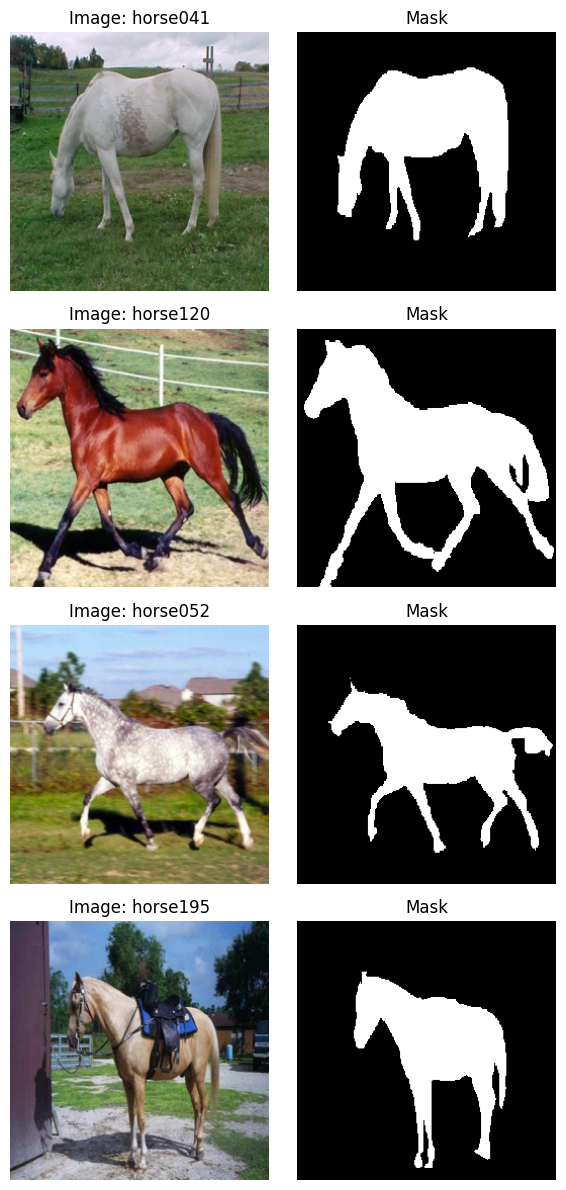

In [ ]:
# === Visualize a few (image, mask) pairs ===

def show_pairs(ds, n=4):
    n = min(n, len(ds))
    idxs = random.sample(range(len(ds)), k=n) if len(ds) >= n else list(range(len(ds)))
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(6, 3*n))
    if n == 1:
        axes = np.array([axes])
    for i, idx in enumerate(idxs):
        img_t, mask_t, name = ds[idx]
        img = img_t.permute(1,2,0).numpy()
        img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))  # de-normalize
        img = np.clip(img, 0, 1)
        mask = mask_t.squeeze().numpy()

        # Try different approaches to visualize the mask
        axes[i,0].imshow(img); axes[i,0].set_title(f"Image: {name}"); axes[i,0].axis('off')

        # Option 1: Direct visualization
        axes[i,1].imshow(mask, cmap='gray'); axes[i,1].set_title("Mask"); axes[i,1].axis('off')


    plt.tight_layout(); plt.show()

if len(dataset) > 0:
    show_pairs(dataset, n=4)  # Start with just 1 sample for debugging
else:
    print("Dataset empty. If auto-download failed, please follow Option B and rerun.")

In [ ]:

# === Train/Val split ===
if len(dataset) >= 10:
    val_ratio = 0.2
    val_len = int(len(dataset)*val_ratio)
    train_len = len(dataset) - val_len
    train_ds, val_ds = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(SEED))
else:
    # Small dataset fallback: use all for train and skip val to just demo pipeline
    train_ds, val_ds = dataset, None

BATCH_SIZE = 5
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True) if val_ds else None

len_train = len(train_ds) if train_ds else 0
len_val = len(val_ds) if val_ds else 0
print(f"Train samples: {len_train} | Val samples: {len_val}")


Train samples: 262 | Val samples: 65



## Implementing a compact U‑Net (PyTorch)

We build a **lightweight U‑Net** suitable for small datasets:

- Each level: `DoubleConv(Conv→BN→ReLU → Conv→BN→ReLU)`
- Downsampling by `MaxPool(2)`; upsampling by `ConvTranspose2d(2×)`
- **Skip connections** via concatenation along channel dimension
- Final `1×1 Conv` ➜ 1 channel; use **BCEWithLogitsLoss** (numerically stable sigmoid)

> In future work (connect to Practicals 4 & 15), you can replace the encoder with a **pretrained backbone** (ResNet etc.) and fine‑tune.


In [ ]:

# === U-Net building blocks ===
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_c=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_c)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_c, base_c*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_c*2, base_c*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_c*4, base_c*8))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_c*8, base_c*16))

        self.up1 = nn.ConvTranspose2d(base_c*16, base_c*8, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(base_c*16, base_c*8)
        self.up2 = nn.ConvTranspose2d(base_c*8, base_c*4, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(base_c*8, base_c*4)
        self.up3 = nn.ConvTranspose2d(base_c*4, base_c*2, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(base_c*4, base_c*2)
        self.up4 = nn.ConvTranspose2d(base_c*2, base_c, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(base_c*2, base_c)

        self.outc = nn.Conv2d(base_c, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv1(x)
        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv2(x)
        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv3(x)
        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv4(x)
        logits = self.outc(x)  # (B,1,H,W)
        return logits

model = UNet().to(DEVICE)
print(model.__class__.__name__, "params:", sum(p.numel() for p in model.parameters())/1e6, "M")


UNet params: 7.763041 M


In [ ]:
# === Loss, Optimizer, and Metrics (patched) ===
criterion = nn.BCEWithLogitsLoss()   # raw logits + targets in {0,1}

def dice_coef(y_true, y_prob, eps=1e-7, thr=0.5):
    """
    y_true: float tensor in {0,1}, shape [B,1,H,W]
    y_prob: probability tensor in [0,1], shape [B,1,H,W]
    """
    y_pred = (y_prob >= thr).float()
    inter = (y_true * y_pred).sum(dim=(1,2,3))
    union = y_true.sum(dim=(1,2,3)) + y_pred.sum(dim=(1,2,3))
    dice = (2*inter + eps) / (union + eps)
    return dice.mean().item()

def iou_score(y_true, y_prob, eps=1e-7, thr=0.5):
    y_pred = (y_prob >= thr).float()
    inter = (y_true * y_pred).sum(dim=(1,2,3))
    union = y_true.sum(dim=(1,2,3)) + y_pred.sum(dim=(1,2,3)) - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()

# Optional: mixed loss for early stabilization
def dice_loss(y_true, y_prob, eps=1e-7):
    inter = (y_true * y_prob).sum(dim=(1,2,3))
    union = y_true.sum(dim=(1,2,3)) + y_prob.sum(dim=(1,2,3))
    dice = (2*inter + eps) / (union + eps)
    return 1 - dice.mean()

lambda_dice = 0.0  # set to 0.3 later if you want BCE+Dice
def mixed_loss(logits, targets):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, targets)
    probs = torch.sigmoid(logits)
    return bce + lambda_dice * dice_loss(targets, probs)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

In [ ]:
# === Training & Validation loops (patched) ===
def run_epoch(dl, model, training: bool):
    if dl is None:
        return None

    model.train(training)
    total_loss, total_dice, total_iou, n_batches = 0.0, 0.0, 0.0, 0

    for imgs, masks, _ in dl:
        imgs = imgs.to(DEVICE, non_blocking=True)    # [B,3,H,W], float
        masks = masks.to(DEVICE, non_blocking=True)  # [B,1,H,W], float {0,1}

        with torch.set_grad_enabled(training):
            logits = model(imgs)                     # [B,1,H,W], raw logits
            # Choose one of the two:
            if lambda_dice > 0.0:
                loss = mixed_loss(logits, masks)
            else:
                loss = criterion(logits, masks)      # BCEWithLogits
            probs = torch.sigmoid(logits)            # for metrics

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_coef(masks.detach(), probs.detach())
        total_iou  += iou_score(masks.detach(), probs.detach())
        n_batches  += 1

    return {
        "loss": total_loss / max(1, n_batches),
        "dice": total_dice / max(1, n_batches),
        "iou" : total_iou  / max(1, n_batches),
    }

EPOCHS = 20  # Keep small for teaching; increase if needed
history = {"train": [], "val": []}

if len_train > 0:
    for epoch in range(1, EPOCHS+1):
        tr = run_epoch(train_loader, model, training=True)
        va = run_epoch(val_loader, model, training=False) if val_loader else None
        history["train"].append(tr)
        history["val"].append(va)
        # Scheduler on validation Dice (if available) else train Dice
        metric_for_lr = (va or tr)["dice"]
        scheduler.step(metric_for_lr)

        msg = f"[{epoch:02d}/{EPOCHS}]  Train: loss={tr['loss']:.4f} dice={tr['dice']:.4f} iou={tr['iou']:.4f}"
        if va:
            msg += f"  |  Val: loss={va['loss']:.4f} dice={va['dice']:.4f} iou={va['iou']:.4f}"
        print(msg)
else:
    print("Training skipped because dataset is empty. Please ensure data is prepared.")


[01/20]  Train: loss=0.1211 dice=0.9026 iou=0.8278  |  Val: loss=0.1310 dice=0.8967 iou=0.8169
[02/20]  Train: loss=0.1153 dice=0.9072 iou=0.8349  |  Val: loss=0.1224 dice=0.9035 iou=0.8274
[03/20]  Train: loss=0.1042 dice=0.9170 iou=0.8502  |  Val: loss=0.1076 dice=0.9138 iou=0.8450
[04/20]  Train: loss=0.0947 dice=0.9243 iou=0.8619  |  Val: loss=0.1050 dice=0.9176 iou=0.8515
[05/20]  Train: loss=0.1046 dice=0.9156 iou=0.8492  |  Val: loss=0.1282 dice=0.9034 iou=0.8291
[06/20]  Train: loss=0.0959 dice=0.9237 iou=0.8615  |  Val: loss=0.0961 dice=0.9206 iou=0.8554
[07/20]  Train: loss=0.0805 dice=0.9352 iou=0.8807  |  Val: loss=0.0965 dice=0.9249 iou=0.8623
[08/20]  Train: loss=0.0737 dice=0.9410 iou=0.8900  |  Val: loss=0.0916 dice=0.9302 iou=0.8722
[09/20]  Train: loss=0.0675 dice=0.9467 iou=0.8998  |  Val: loss=0.1133 dice=0.9165 iou=0.8492
[10/20]  Train: loss=0.0733 dice=0.9421 iou=0.8919  |  Val: loss=0.1146 dice=0.9088 iou=0.8382
[11/20]  Train: loss=0.0885 dice=0.9301 iou=0.8723

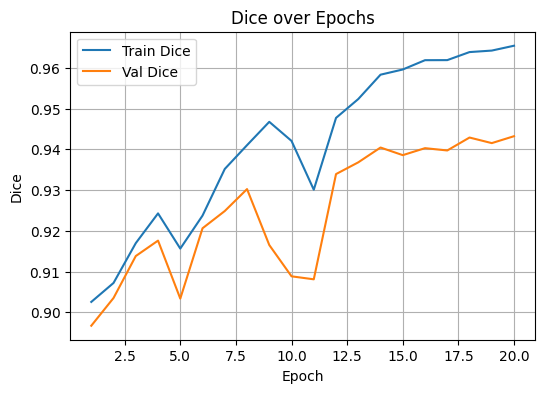

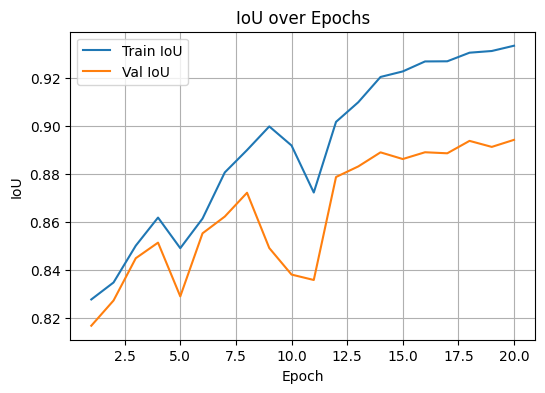

In [ ]:

# === Plot learning curves ===
def plot_history(history):
    # Separate plots for Dice and IoU (no explicit colors/styles as per instructions)
    epochs = range(1, len(history["train"])+1)
    # Dice
    plt.figure(figsize=(6,4))
    plt.plot(epochs, [t["dice"] for t in history["train"]], label="Train Dice")
    if history["val"][0] is not None:
        plt.plot(epochs, [v["dice"] if v else None for v in history["val"]], label="Val Dice")
    plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice over Epochs"); plt.legend(); plt.grid(True)
    plt.show()
    # IoU
    plt.figure(figsize=(6,4))
    plt.plot(epochs, [t["iou"] for t in history["train"]], label="Train IoU")
    if history["val"][0] is not None:
        plt.plot(epochs, [v["iou"] if v else None for v in history["val"]], label="Val IoU")
    plt.xlabel("Epoch"); plt.ylabel("IoU"); plt.title("IoU over Epochs"); plt.legend(); plt.grid(True)
    plt.show()

if len_train > 0:
    plot_history(history)


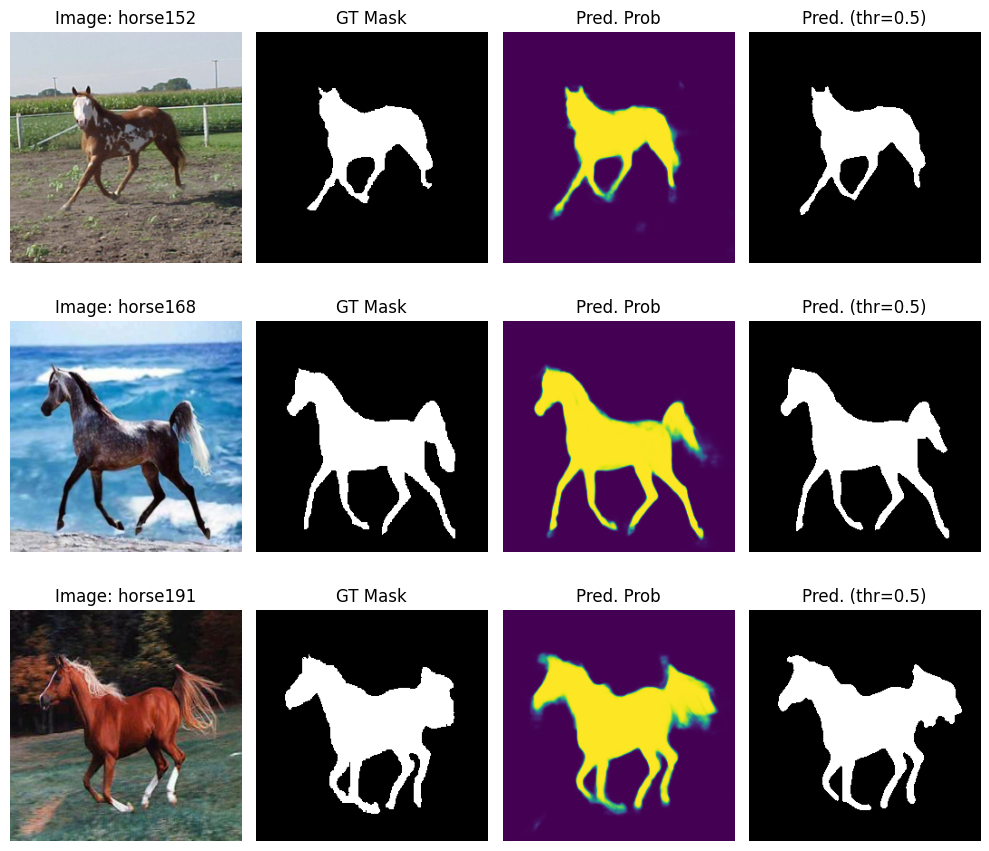

In [ ]:

# === Visualize predictions on a few samples ===
def visualize_predictions(model, ds, n=4, thr=0.5):
    model.eval()
    n = min(n, len(ds))
    idxs = random.sample(range(len(ds)), k=n) if len(ds) >= n else list(range(len(ds)))
    fig, axes = plt.subplots(nrows=n, ncols=4, figsize=(10, 3*n))
    if n == 1:
        axes = np.array([axes])
    for i, idx in enumerate(idxs):
        img_t, mask_t, name = ds[idx]
        with torch.no_grad():
            logits = model(img_t.unsqueeze(0).to(DEVICE))
            prob = torch.sigmoid(logits).cpu().squeeze().numpy()
        pred = (prob >= thr).astype(np.float32)

        # De-normalize image
        img = img_t.permute(1,2,0).numpy()
        img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
        img = np.clip(img, 0, 1)

        axes[i,0].imshow(img); axes[i,0].set_title(f"Image: {name}"); axes[i,0].axis('off')
        axes[i,1].imshow(mask_t.squeeze().numpy(), cmap='gray', vmin=0, vmax=1); axes[i,1].set_title("GT Mask"); axes[i,1].axis('off')
        axes[i,2].imshow(prob, vmin=0, vmax=1); axes[i,2].set_title("Pred. Prob"); axes[i,2].axis('off')
        axes[i,3].imshow(pred, cmap='gray', vmin=0, vmax=1); axes[i,3].set_title(f"Pred. (thr={thr})"); axes[i,3].axis('off')
    plt.tight_layout(); plt.show()

if len_train > 0:
    visualize_predictions(model, val_ds if val_ds else train_ds, n=3, thr=0.5)



## Exercises (for practice)
1. **Architecture tweak:** Change `base_c` from 32 → 16 or 64. How do params and accuracy change?
2. **Augmentations:** Add random rotation/crop; report effect on Dice/IoU.
3. **Learning rate & epochs:** Try `lr=5e‑4` and `EPOCHS=50`. Plot new curves.
4. **Threshold sweep:** Compute Dice for thresholds in `[0.3, 0.9]` (step=0.05) and plot.
5. **Transfer idea:** Swap the encoder with a pretrained ResNet (Practical 4/15 connection).


In [ ]:

# === Save model checkpoint ===
ckpt_dir = Path("checkpoints"); ckpt_dir.mkdir(exist_ok=True, parents=True)
ckpt_path = ckpt_dir / "unet_weizmann_horse.pt"
if len_train > 0:
    torch.save({"model_state": model.state_dict(),
                "meta": {"arch": "UNet", "img_size": 256, "date": time.ctime()}},
               ckpt_path)
    print(f"Saved: {ckpt_path.resolve()}")
else:
    print("No training done; skipping save.")


Saved: D:\CV\notebooks\checkpoints\unet_weizmann_horse.pt



## Recap & Next Steps
- You implemented **U‑Net** and trained it for **binary horse segmentation**.
- You practiced **IoU/Dice** metrics and visual evaluation.
- You learned how **skip connections** recover spatial details for precise masks.

**Next:** **Practical 23: Multi‑Class Segmentation** (softmax output + per‑class metrics)


---
📝 This practical was designed to give you a concise, hands-on introduction to **binary image segmentation** with **U-Net** on the **Weizmann Horse** dataset.